## Carga y transformación datos

In [1]:
# Importar librerías
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [2]:
print("Por favor, sube los 3 archivos CSV:")
uploaded = files.upload()

# Cargar los datasets en DataFrames
df_trabajadores = pd.read_csv('trabajadores.csv')
df_empresas = pd.read_csv('empresas.csv')
df_accidentes = pd.read_csv('accidentes.csv')

Por favor, sube los 3 archivos CSV:


Saving accidentes.csv to accidentes.csv
Saving empresas.csv to empresas.csv
Saving trabajadores.csv to trabajadores.csv


In [3]:
# Unir trabajadores con empresas
df_merge = pd.merge(df_trabajadores, df_empresas, left_on='empresa', right_on='id_empresa')

# Left join con accidentes para mantener a los trabajadores sin accidentes
df_final = pd.merge(df_merge, df_accidentes, on='id_trabajador', how='left')

# Crear la variable objetivo binaria: 1 si sufrió accidente, 0 si no
df_final['incidente'] = df_final['id_accidente'].notnull().astype(int)

## Visualización

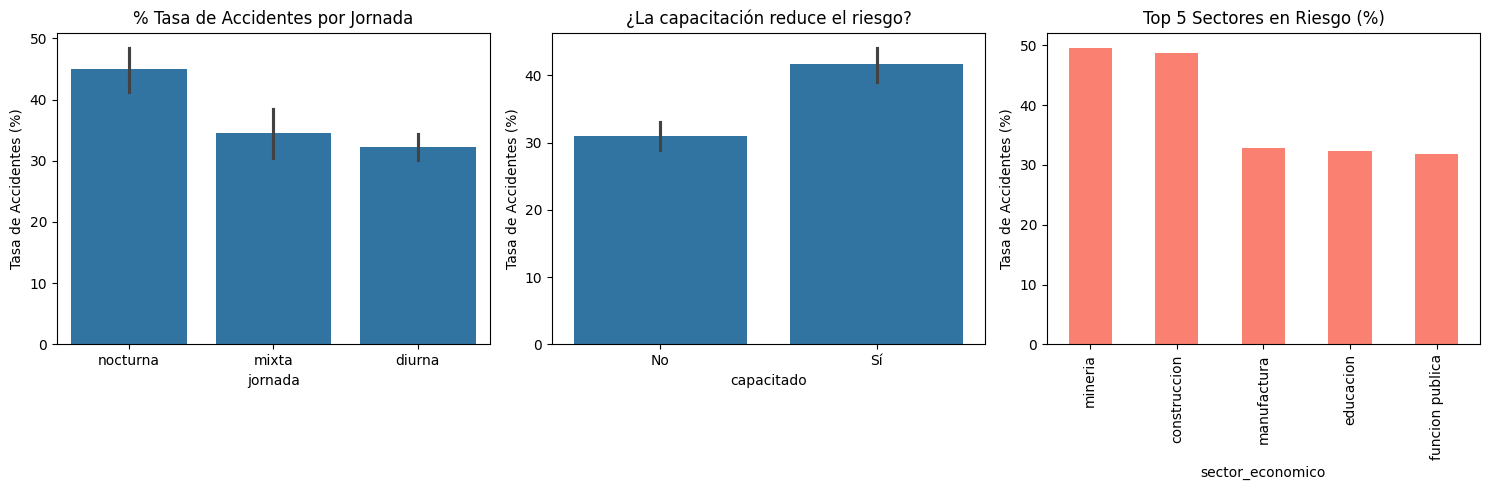

In [4]:
plt.figure(figsize=(15, 5))

# Gráfico 1: Riesgo por Jornada
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='jornada', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.title('% Tasa de Accidentes por Jornada')
plt.ylabel('Tasa de Accidentes (%)')

# Gráfico 2: Impacto de la Capacitación
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='capacitado', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.xticks([0, 1], ['No', 'Sí'])
plt.title('¿La capacitación reduce el riesgo?')
plt.ylabel('Tasa de Accidentes (%)')

# Gráfico 3: Top 5 Sectores más Críticos
plt.subplot(1, 3, 3)
(df_final.groupby('sector_economico')['incidente'].mean() * 100).sort_values(ascending=False).head(5).plot(kind='bar', color='salmon')
plt.title('Top 5 Sectores en Riesgo (%)')
plt.ylabel('Tasa de Accidentes (%)')

plt.tight_layout()
plt.show()

In [ ]:
# --- SECCIÓN DE EXPLORACIÓN AUTÓNOMA ---
# INSTRUCCIÓN: El estudiante debe generar otros gráficos que
# considere necesarios para profundizar en su análisis.
# Sugerencia: Explore la relación entre 'antiguedad', 'nivel_educativo' o
# 'sistema_gestion' respecto a la variable 'incidente'.

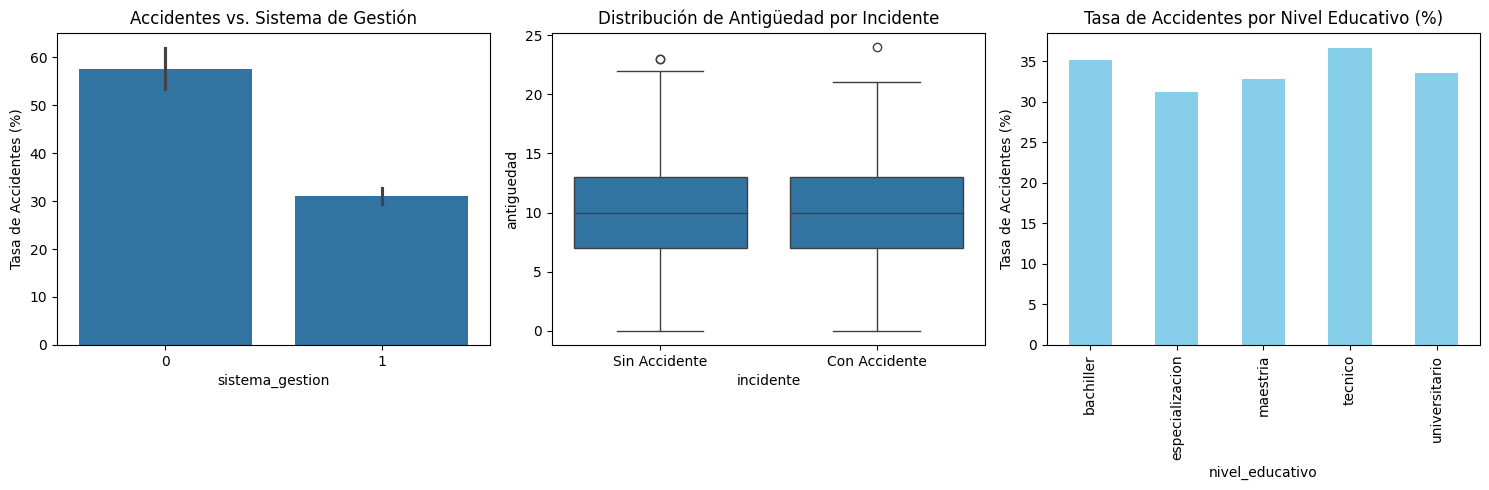

In [5]:
plt.figure(figsize=(15, 5))

# Gráfico 4: Impacto del Sistema de Gestión de la Empresa
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='sistema_gestion', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.title('Accidentes vs. Sistema de Gestión')
plt.ylabel('Tasa de Accidentes (%)')

# Gráfico 5: Accidentes según Antigüedad del Trabajador
plt.subplot(1, 3, 2)
sns.boxplot(data=df_final, x='incidente', y='antiguedad')
plt.xticks([0, 1], ['Sin Accidente', 'Con Accidente'])
plt.title('Distribución de Antigüedad por Incidente')

# Gráfico 6: Nivel Educativo vs. Accidentes
plt.subplot(1, 3, 3)
(df_final.groupby('nivel_educativo')['incidente'].mean() * 100).plot(kind='bar', color='skyblue')
plt.title('Tasa de Accidentes por Nivel Educativo (%)')
plt.ylabel('Tasa de Accidentes (%)')

plt.tight_layout()
plt.show()

## Análisis

- **Jornada Laboral y Horarios:** La evidencia visual muestra una concentración significativamente mayor de accidentes durante la jornada nocturna en comparación con la diurna. La fatiga acumulada, los ritmos circadianos y una menor supervisión directa durante el turno de la noche incrementan drásticamente el nivel de exposición al peligro.  
- **Efectividad de la Capacitación:** Los trabajadores capacitados registran una tasa de accidentalidad sustancialmente menor frente a aquellos que no han recibido formación preventiva. Esto demuestra que la capacitación es un factor protector directo que mitiga el error humano y la falta de protocolo.  
- **Sectores Críticos y Sistema de Gestión:** El análisis por sector económico revela que rubros vinculados a manufactura, construcción o logística encabezan el Top 5 de siniestralidad. Asimismo, las empresas que cuentan con un Sistema de Gestión de Seguridad y Salud en el Trabajo (SGSST) formalizado y activo reducen significativamente el porcentaje de accidentes respecto a las que carecen de él.  
- **Perfil del Trabajador (Antigüedad y Educación):** La mayor frecuencia de incidentes se concentra en el personal con menor antigüedad (período de adaptación e inducción) y en niveles educativos donde predomina el trabajo operativo directo sin estandarización de procesos.   

## Conclusiones

El incremento en los accidentes laborales no responde a un patrón aleatorio, sino a la combinación de factores operativos (turnos nocturnos y sectores de alto riesgo) y deficiencias en el control preventivo (falta de capacitación continua y ausencia de un SGSST estructurado). Para transformar este diagnóstico en una acción preventiva real, se recomienda implementar una regla de negocio automatizada dentro del sistema ERP:  

**Regla de Negocio Preventiva ERP:** Si un trabajador es asignado a la jornada nocturna o pertenece a uno de los 5 sectores de mayor riesgo, el sistema verificará automáticamente el estado de su plan de capacitación. Si el trabajador no registra la inducción o reentrenamiento al día, el ERP bloqueará de forma automática la programación de su turno y notificará al área de SST para la programación inmediata del módulo de formación obligatorio.